# Electric Vehicles in Washington State

-- -

## Introduction:
### This project studies the State of Washington data base of electric vehicles from the oldest model of 1997 to the newest ones in 2024

-- -

## Problem Statement:
### Electric Vehicles companies struggle to compete with TESLA in terms of number of vehicles based on Washington State data base; with TESLA holding %45 and the closest competitor has %8

-- -

## Objectives:
#### • Identify the variables that affect the electric vehicles market
#### • Visualize the growth of the EV market over the years
#### • Determine the percentage of CAFV-eligible vehicles
#### • Compare the percentages of CAFV-eligible vehicles between TESLA and the other manufacturers
#### • Determine the percentages of each battery type
#### • Compare the EV range between TESLA and the other manufacturers
#### • Provide data-driven recommendations for other manufacturers to compete with TESLA


-- -

## Exploratory Data Analysis (EDA):

### Data Info and Data Handling:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

In [3]:
df.sample(3)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
166570,5YJ3E1EA7J,Pierce,Puyallup,WA,98374.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,25.0,311589400,POINT (-122.275748 47.1395924),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
105284,5YJ3E1EB6P,King,Kirkland,WA,98034.0,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,224705827,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
25707,5YJYGAEE8M,King,Renton,WA,98056.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,41.0,156810489,POINT (-122.180505 47.500055),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  str    
 1   County                                             177861 non-null  str    
 2   City                                               177861 non-null  str    
 3   State                                              177866 non-null  str    
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  str    
 7   Model                                              177866 non-null  str    
 8   Electric Vehicle Type                              177866 non-null  str    
 9   Clea

In [5]:
df.rename(columns={'Clean Alternative Fuel Vehicle (CAFV) Eligibility':'CAFV Eligibility'},inplace=True)

- shortening the name of the column for the ease of use

In [6]:
df.shape

(177866, 17)

##### checking for duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

##### checking for nulls

In [8]:
df.isna().sum()

VIN (1-10)                 0
County                     5
City                       5
State                      0
Postal Code                5
Model Year                 0
Make                       0
Model                      0
Electric Vehicle Type      0
CAFV Eligibility           0
Electric Range             0
Base MSRP                  0
Legislative District     389
DOL Vehicle ID             0
Vehicle Location           9
Electric Utility           5
2020 Census Tract          5
dtype: int64

- we can ignore these nulls because we don't need them for our analysis

#### - Checking the numerical columns

In [9]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,177861.000000,177866.000000,177866.000000,177866.000000,177477.000000,1.778660e+05,1.778610e+05
mean,98172.453506,2020.515512,58.842162,1073.109363,29.127481,2.202313e+08,5.297672e+10
std,2442.450668,2.989384,91.981298,8358.624956,14.892169,7.584987e+07,1.578047e+09
min,1545.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2019.000000,0.000000,0.000000,18.000000,1.814743e+08,5.303301e+10
50%,98122.000000,2022.000000,0.000000,0.000000,33.000000,2.282522e+08,5.303303e+10
75%,98370.000000,2023.000000,75.000000,0.000000,42.000000,2.548445e+08,5.305307e+10
max,99577.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


- we have zeros in "Electric Range" and "Base MSRP" which doesn't make sense

#### - Calculating the percentage of zeros in the 'Electric Range' column

In [10]:
100*(df[df['Electric Range']==0]['VIN (1-10)'].count())/df['VIN (1-10)'].count()

np.float64(51.69622075045259)

- `% 51.69` is missing the electric range value

#### - Calculating the percentage of zeros in the 'Base MSRP' column

In [11]:
100*(df[df['Base MSRP']==0]['VIN (1-10)'].count())/df['VIN (1-10)'].count()

np.float64(98.11993298325706)

- `% 98.12` is missing the Base MSRP

### Analysis

#### - Checking the number of vehicles based on the 'Make'

In [12]:
df['Make'].value_counts()

Make
TESLA                   79659
NISSAN                  13998
CHEVROLET               13678
FORD                     9199
BMW                      7570
KIA                      7432
TOYOTA                   6288
VOLKSWAGEN               5004
JEEP                     4480
HYUNDAI                  4406
RIVIAN                   4312
VOLVO                    4133
AUDI                     3646
CHRYSLER                 2993
MERCEDES-BENZ            1589
PORSCHE                  1139
MITSUBISHI                958
MINI                      898
POLESTAR                  882
HONDA                     833
SUBARU                    831
FIAT                      784
DODGE                     568
MAZDA                     476
CADILLAC                  382
LEXUS                     370
SMART                     270
LINCOLN                   267
LUCID                     240
JAGUAR                    232
GENESIS                   182
LAND ROVER                 56
FISKER                     49
ALFA 

In [13]:
df["is_TESLA"] = np.where(
    df["Make"] == "TESLA",
    "TESLA",
    "others"
)

In [14]:
100*df[df['is_TESLA']=="TESLA"].Make.count()/df.Make.count()

np.float64(44.785962466126186)

In [15]:
100*df[df['is_TESLA']=="others"].Make.count()/df.Make.count()

np.float64(55.214037533873814)

In [16]:
100*df[df['Make']=="NISSAN"].Make.count()/df.Make.count()

np.float64(7.869969527621918)

- `% 44.79` of EV in the data base are TESLA's

- `% 55.21` all the other competetors combined

- `% 7.87` is the percentage of NISSAN EVs the closest competitor to TESLA

#### - Visualizing the growth of the EV market

In [17]:
df['Model Year'].value_counts()

Model Year
2023    57587
2022    27776
2021    19132
2018    14323
2020    11768
2019    10940
2017     8562
2024     7080
2016     5483
2015     4844
2013     4409
2014     3509
2012     1618
2011      775
2010       23
2008       20
2000        7
1999        5
2002        2
1998        1
1997        1
2003        1
Name: count, dtype: int64

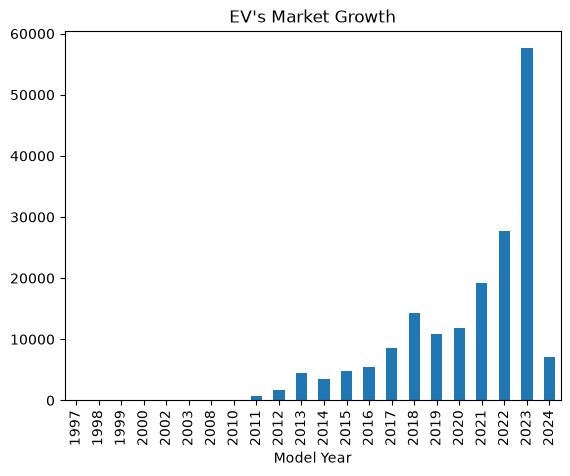

In [18]:
df['Model Year'].value_counts().sort_index(ascending=True).plot(kind='bar',title="EV's Market Growth");

- Based on the growth trend it is safe to assume that the data frame is up to 2024 and doesn't include all the 2024 vehicles

#### - Visualizing the growth of TESLA compared to the others

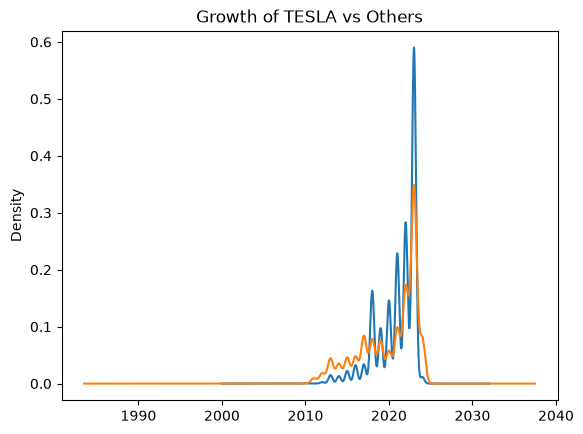

In [19]:
df.groupby('is_TESLA')['Model Year'].plot(kind='density',title="Growth of TESLA vs Others");

- TESLA is the blue line and the others combined is the orange one

#### - Calculating the percentage of CAFV Eligibility 

In [20]:
df['CAFV Eligibility'].value_counts()

CAFV Eligibility
Eligibility unknown as battery range has not been researched    91950
Clean Alternative Fuel Vehicle Eligible                         66331
Not eligible due to low battery range                           19585
Name: count, dtype: int64

In [21]:
CAFV_E=df[df['CAFV Eligibility']=='Clean Alternative Fuel Vehicle Eligible']['CAFV Eligibility'].count()

In [22]:
CAFV_NE=df[df['CAFV Eligibility']=='Not eligible due to low battery range']['CAFV Eligibility'].count()

In [23]:
CAFV_U=df[df['CAFV Eligibility']=='Eligibility unknown as battery range has not been researched']['CAFV Eligibility'].count()

In [24]:
# percentage of not researched CAFV
100*CAFV_U/df['CAFV Eligibility'].count()

np.float64(51.69622075045259)

In [25]:
# percentage of not researched CAFV
100-(100*CAFV_U/df['CAFV Eligibility'].count())

np.float64(48.30377924954741)

- `% 51.70` of the EV's in the data frame is not researched for the CAFV
- `% 48.30` of the EV's in the data frame is researched for the CAFV

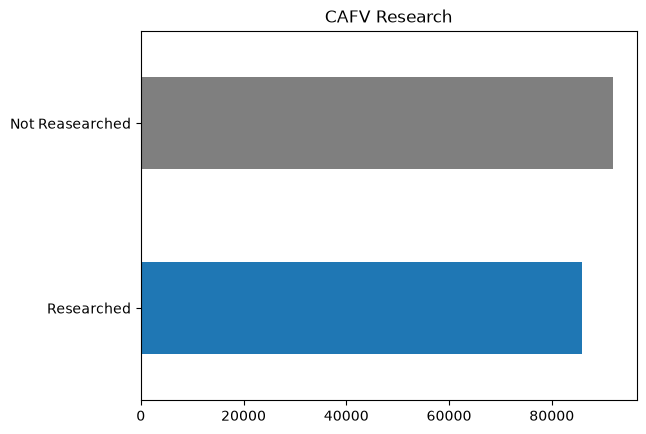

In [26]:
pd.Series({"Researched":CAFV_NE+CAFV_E,"Not Reasearched":CAFV_U,}).plot(kind='barh',color=['tab:blue','tab:grey'],title="CAFV Research");

#### - Comparing the percentages of CAFV between TESLA and competetors

In [27]:
df[df['Electric Range']>0].groupby('is_TESLA')["CAFV Eligibility"].value_counts()

is_TESLA  CAFV Eligibility                       
TESLA     Clean Alternative Fuel Vehicle Eligible    25582
others    Clean Alternative Fuel Vehicle Eligible    40749
          Not eligible due to low battery range      19585
Name: count, dtype: int64

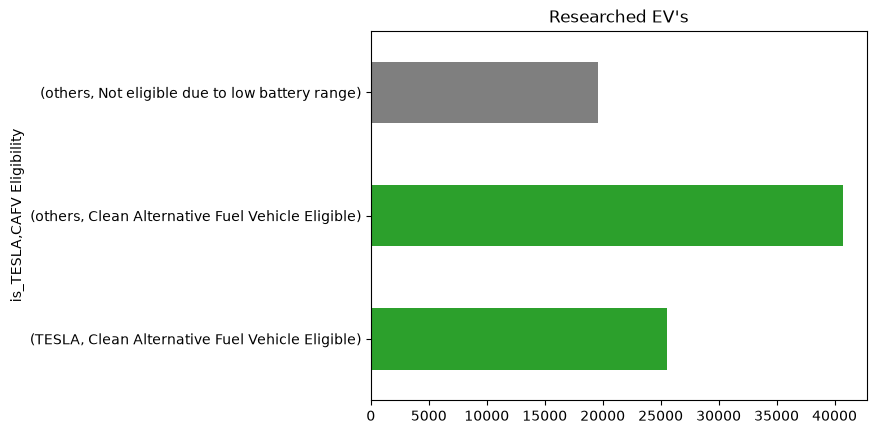

In [28]:
df[df['Electric Range']>0].groupby('is_TESLA')["CAFV Eligibility"].value_counts().plot(kind='barh',title="Researched EV's",color=['tab:green','tab:green','tab:grey']);

In [29]:
others_CAFV=df[(df['Electric Range']>0)&(df['is_TESLA']=='others')&(df["CAFV Eligibility"]=="Clean Alternative Fuel Vehicle Eligible")].Make.count()

In [30]:
others_not_CAFV=df[(df['Electric Range']>0)&(df['is_TESLA']=='others')&(df["CAFV Eligibility"]=="Not eligible due to low battery range")].Make.count()

In [31]:
#percentage of CAFV Eligible from the others and excluding the not researched
100*others_CAFV/(others_CAFV+others_not_CAFV)

np.float64(67.53903271787053)

- `% 100` of TESLA vehicles are CAFV Eligibie
- `% 67.54` of other vehicles are CAFV Eligible

#### - Visualizing the types of EV's

In [32]:
df['Electric Vehicle Type'].value_counts()

Electric Vehicle Type
Battery Electric Vehicle (BEV)            139210
Plug-in Hybrid Electric Vehicle (PHEV)     38656
Name: count, dtype: int64

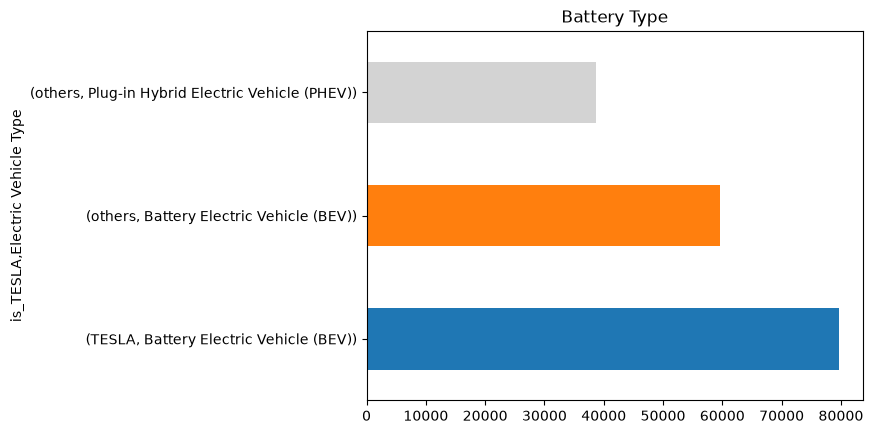

In [33]:
df.groupby('is_TESLA')['Electric Vehicle Type'].value_counts().plot(kind='barh',title="Battery Type",color=['tab:blue','tab:orange','lightgrey']);

#### - Comparing the ranges between TESLA and others after excluding the Hybrid Vehicles

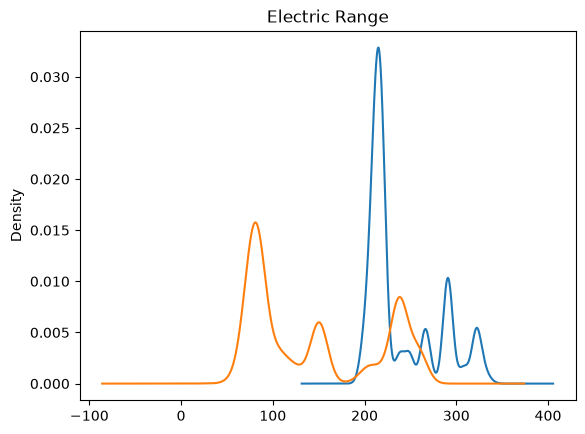

In [34]:
df[(df['Electric Range']>0)&(df['Electric Vehicle Type']=="Battery Electric Vehicle (BEV)")].groupby('is_TESLA')['Electric Range'].plot(kind='density',title="Electric Range");

In [35]:
df[(df['is_TESLA']=="TESLA")&(df['Electric Range']>0)]["Electric Range"].agg(['min','mean','max'])

min     200.000000
mean    240.821046
max     337.000000
Name: Electric Range, dtype: float64

- The `minimum` range of TESLA's is `200`
- The `average` range of TESLA's is `240.82`
- The `maximum` range of TESLA's is `337`

In [36]:
df[(df['is_TESLA']=="others")&(df['Electric Range']>0)&(df['Electric Vehicle Type']=="Battery Electric Vehicle (BEV)")]["Electric Range"].agg(['min','mean','max'])

min      29.000000
mean    143.671234
max     259.000000
Name: Electric Range, dtype: float64

- The `minimum` range of others is `29`
- The `average` range of others is `143.67`
- The `maximum` range of others is `259`

#### - Showing the top 5 EV's in term of range

In [37]:
df[df['Electric Range']>0].groupby('Model')['Electric Range'].max().sort_values(ascending=False).head(5)

Model
MODEL S    337
MODEL 3    322
MODEL X    293
MODEL Y    291
BOLT EV    259
Name: Electric Range, dtype: int64

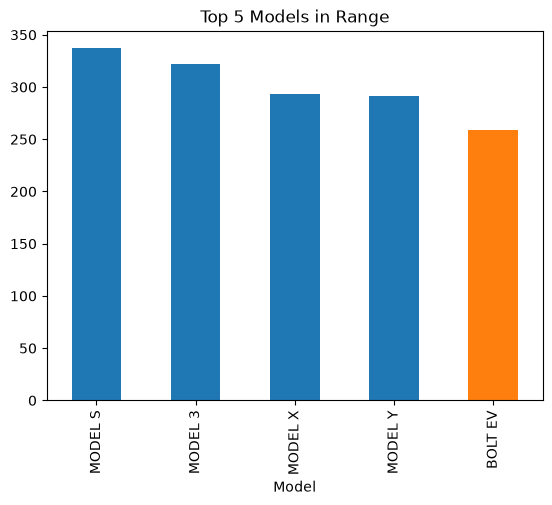

In [38]:
df.groupby('Model')['Electric Range'].max().sort_values(ascending=False).head(5).plot(kind='bar',color=['tab:blue','tab:blue','tab:blue','tab:blue','tab:orange'],title="Top 5 Models in Range");

#### - Showing the top 5 EV's in term of total count

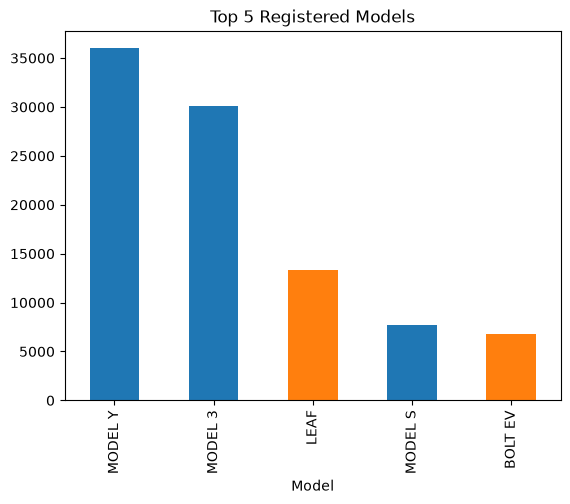

In [40]:
df[df['Electric Vehicle Type']=="Battery Electric Vehicle (BEV)"]['Model'].value_counts().head(5).plot(kind='bar',
                                                                                                       color=['tab:blue','tab:blue','tab:orange','tab:blue','tab:orange'],
                                                                                                      title="Top 5 Registered Models");

- We see that the 3 of the TESLA's are in top 5 in range and in sold

-- -

## Summary:
#### - After visualizing the growth we see that TESLA growth is huge compared to the others
#### - After excluding the not researched EV's we see that All the TESLA's are CAFV Eligible and only `% 67.54` of the other EV's are CAFV Eligible
#### - After excluding the Hybrid Vehicles we saw that the ranges of TESLA's are far better on average
#### - The average range of TESLA's is `240.82`
#### - The average range of the Others is `143.67`
#### - We compared the top 5 models in range and top 5 models in total registered vehicles and found that 3 TESLA models are on both lists

## Conclusion:

#### • The significant amount of missing Base MSRP data limited our ability to include vehicle price in the analysis
#### • Electric range appears to have a significant impact on the number of  registered vehicles , suggesting that increasing the range of future models could help improve sales performance.
#### • All researched Tesla vehicles in the analysis were CAFV eligible, which may have contributed to their appeal while the tax incentive was available. However, new vehicle sales and leases after July 31, 2025 no longer qualify for this exemption
